# Two Leading lepton $p_t$ and two leading lepton $\eta$.

In this notebook, we will look at events with two leading lepton $p_t$ and their corresponding EFT coefficients. At the end, we will also look at their $\eta$ values. 

### Import packages

In [2]:
import uproot
import awkward as ak
import matplotlib.pyplot as plt
import numpy as np

### Names for each pair

In [3]:
# Names from json file:
names_json = ["SM","cQu8","ctu8","cQu1","ctd8","cQlMi","cpQ3","ctlTi","ctG","ctZ","ctW","ctli","ctb8","cbW","cQl3i","cQq13",
              "cptb","ctp","ctei","cpQM","ctlSi", "cQq83","cQq81","ctq1","ctu1","cQei","cQb8","cpt","ctq8","cQd1","cQq11",
              "cQd8","ctd1"]

# All 561 combinations of coefficients (i.e SM,SM; SM,cQu8; cQu8,cQu8; SM,ctu8; cQu8,ctu8; ...)
name_combinations = []
for i in range(len(names_json)):
    for a in range(i+1):
        name_combinations.append([names_json[i],names_json[a]])

### Open file and branches

In [4]:
# Open file
file = uproot.open("sample_root_files/output_570.root")
# Open events tree
events_tree = file['Events']
# Open EFTFitCoefficients branch:
eft_coeff = events_tree['EFTfitCoefficients'].array()
jet_pt = events_tree['Jet_pt'].array()

## Sneha's code to find two leading lepton $p_t$ in each event

In [5]:
elec_pt = events_tree['Electron_pt'].array()
mu_pt = events_tree['Muon_pt'].array()
tau_pt = events_tree['Tau_pt'].array()

elec_eta = events_tree['Electron_eta'].array()
mu_eta = events_tree['Muon_eta'].array()
tau_eta = events_tree['Tau_eta'].array()

In [6]:
%%time
# leptons can be either electron muon or tau. 
# pick two leading leptons and then sum their pt.
# TODO : output an array with the two leading leptons for each event. 


two_leading_leptons = [[]]
for i in range(len(elec_pt)):
    leading_pts, ptlist = [],[]
    ptlist.extend(elec_pt[i])
    ptlist.extend(mu_pt[i]) 
    ptlist.extend(tau_pt[i])
    leading_pts.append(max(ptlist))
    ptlist.remove(max(ptlist))
    leading_pts.append(max(ptlist))
    two_leading_leptons.append(leading_pts)

two_leading_leptons = np.array(two_leading_leptons[1:])

CPU times: user 11.7 s, sys: 26.5 ms, total: 11.7 s
Wall time: 11.8 s


### Separating between first and second lepton (first is largest $p_t$, second is second largest $p_t$) 

In [7]:
sneha_first_lepton = two_leading_leptons[:,0]
sneha_second_lepton = two_leading_leptons[:,1]

### Finding largest EFT Coefficient for each event above cutoff

In [8]:
def eft_coeff_leptons(data, cutoff):
    cut_list = data > cutoff
    eft_coeff_lepton = []
    
    for i,n in enumerate(cut_list):                                       
        if n == True:
            eft_coeff_lepton.append(np.argmax(np.abs(eft_coeff[i][1:])) + 1)
            # +1 since the new list gets shifted by ignoring the first coefficient, but np.argmax doesn't know this...
            
    return(eft_coeff_lepton)

In [57]:
%%time
# Running function for first lepton with cutoff at 50 GeV and second lepton with cutoff at 30 GeV
eft_coeff_sneha_first_lepton = np.array(eft_coeff_leptons(sneha_first_lepton, 50))
eft_coeff_sneha_second_lepton = np.array(eft_coeff_leptons(sneha_second_lepton, 30))

CPU times: user 54.1 s, sys: 186 ms, total: 54.3 s
Wall time: 54.6 s


### Printing coefficients that have a frequency above 1% of being largest

In [78]:
def interesting_coeff(data):
    percent_and_index = []
    for i in range(561):
        coeff_percentage = np.count_nonzero(data == i) / len(data)
        if coeff_percentage >= 0.01:
            percent_and_index.append([np.round(coeff_percentage*100, 3), i])
    
           
    percent_and_index = np.array(percent_and_index)
    indices = np.argsort(percent_and_index[:,0])                # This tells me the order of the rows
    percent_and_index_ordered = percent_and_index[indices][::-1] # This sorts the rows based on the indices and [::-1] makes it go in descending order
    
    for i in range(len(percent_and_index_ordered)):
        a = print(f'The pair {name_combinations[round(percent_and_index_ordered[i,1])]} with index {percent_and_index_ordered[i,1]} has {percent_and_index_ordered[i,0]}%')

    return a

### Making function that adds weights (calculates percentages)

In [79]:
def weights(data):
    return [1 / len(data)] * len(data)

### _Results for first lepton_

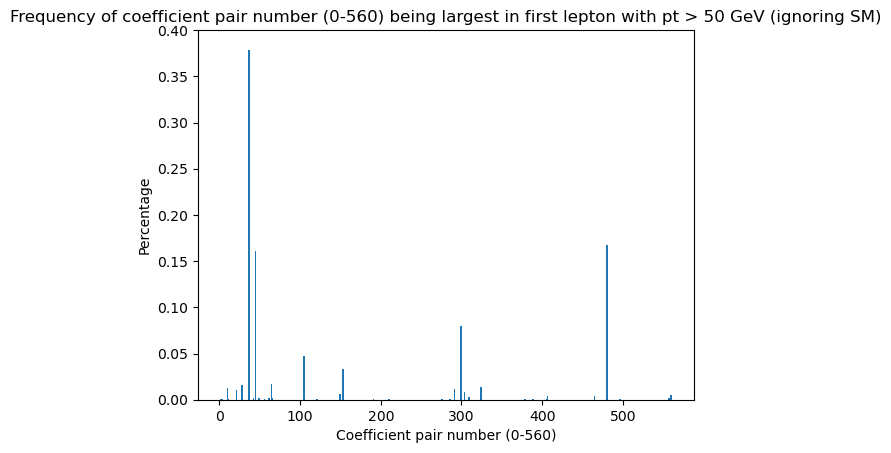

The pair ['ctG', 'SM'] with index 36.0 has 37.81%
The pair ['cQq11', 'cQq13'] with index 480.0 has 16.761%
The pair ['ctG', 'ctG'] with index 44.0 has 16.071%
The pair ['ctq1', 'ctq1'] with index 299.0 has 8.023%
The pair ['cbW', 'cbW'] with index 104.0 has 4.752%
The pair ['cptb', 'cptb'] with index 152.0 has 3.253%
The pair ['ctW', 'ctZ'] with index 64.0 has 1.667%
The pair ['cpQ3', 'cpQ3'] with index 27.0 has 1.616%
The pair ['ctu1', 'ctu1'] with index 324.0 has 1.427%
The pair ['cQu1', 'cQu1'] with index 9.0 has 1.282%
The pair ['ctq1', 'cQq13'] with index 291.0 has 1.199%
The pair ['cpQ3', 'SM'] with index 21.0 has 1.067%


In [80]:
# Plotting histogram for first lepton and also printing the interesting coefficients (higher than 5%)
plt.hist(eft_coeff_sneha_first_lepton, bins = 500, weights = weights(eft_coeff_sneha_first_lepton), width = 2)
plt.xlabel('Coefficient pair number (0-560)')
plt.ylabel('Percentage')
plt.title('Frequency of coefficient pair number (0-560) being largest in first lepton with pt > 50 GeV (ignoring SM)')
plt.ylim(0,0.4)
plt.show()

interesting_coeff(eft_coeff_sneha_first_lepton)

### _Results for second lepton_

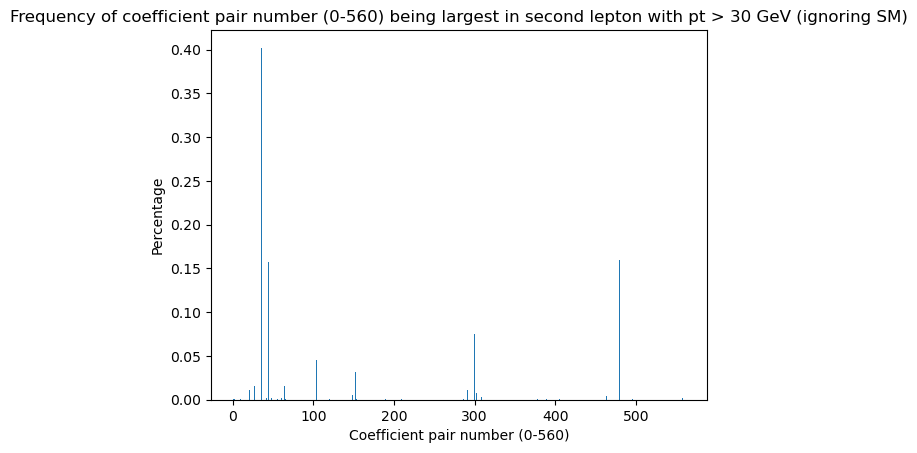

The pair ['ctG', 'SM'] with index 36.0 has 40.211%
The pair ['cQq11', 'cQq13'] with index 480.0 has 15.942%
The pair ['ctG', 'ctG'] with index 44.0 has 15.718%
The pair ['ctq1', 'ctq1'] with index 299.0 has 7.512%
The pair ['cbW', 'cbW'] with index 104.0 has 4.584%
The pair ['cptb', 'cptb'] with index 152.0 has 3.164%
The pair ['ctW', 'ctZ'] with index 64.0 has 1.537%
The pair ['cpQ3', 'cpQ3'] with index 27.0 has 1.532%
The pair ['ctu1', 'ctu1'] with index 324.0 has 1.34%
The pair ['cQu1', 'cQu1'] with index 9.0 has 1.198%
The pair ['cpQ3', 'SM'] with index 21.0 has 1.165%
The pair ['ctq1', 'cQq13'] with index 291.0 has 1.123%


In [81]:
# Plotting histogram for second lepton and also the interesting coefficients (higher than 5%)
plt.hist(eft_coeff_sneha_second_lepton, bins = 520, weights = weights(eft_coeff_sneha_second_lepton))
plt.xlabel('Coefficient pair number (0-560)')
plt.ylabel('Percentage')
plt.title('Frequency of coefficient pair number (0-560) being largest in second lepton with pt > 30 GeV (ignoring SM)')
plt.show()

interesting_coeff(eft_coeff_sneha_second_lepton)

## My code to find two leading lepton $p_t$ and two leading lepton $\eta$

In [17]:
%%time

leading_leptons_pt = []
leading_leptons_eta = []

for i in range(len(elec_pt)):
    lepton_pt = np.concatenate((elec_pt[i],mu_pt[i],tau_pt[i]), axis = 0)         # concatenating all lepton pt and lepton eta
    lepton_eta = np.concatenate((elec_eta[i],mu_eta[i],tau_eta[i]), axis = 0)      
    order = np.argsort(lepton_pt)                                                 # order for values in ascending order
    lepton_pt_sorted = lepton_pt[order]                                           # sorting the lepton pt and lepton eta using the order given above
    lepton_eta_sorted = lepton_eta[order]                                          
    leading_leptons_pt.append([lepton_pt_sorted[-1],lepton_pt_sorted[-2]])        # appending largest values for lepton pt and lepton eta
    leading_leptons_eta.append([lepton_eta_sorted[-1],lepton_eta_sorted[-2]])

leading_leptons_pt = np.array(leading_leptons_pt)
leading_leptons_eta = np.array(leading_leptons_eta)

CPU times: user 1min 15s, sys: 570 ms, total: 1min 16s
Wall time: 1min 16s


##### Found faster way

Concatenating and sorting the $p_t$ and $\eta$ based on the $p_t$ order!

In [82]:
%%time
all_pts = np.concatenate((elec_pt, mu_pt, tau_pt), axis = 1)
all_etas = np.concatenate((elec_eta, mu_eta, tau_eta), axis = 1)

order = np.argsort(all_pts)

all_pts_sorted = all_pts[order]
all_etas_sorted = all_etas[order]

# Getting first and second leptons
first_leptons_pt = all_pts_sorted[:,-1]
second_leptons_pt = all_pts_sorted[:,-2]
leading_leptons_pt1 = np.stack((first_leptons_pt, second_leptons_pt), axis=1) # Stacking them!

# Getting first and second etas
first_leptons_eta = all_etas_sorted[:,-1]
second_leptons_eta = all_etas_sorted[:,-2]
leading_leptons_eta1 = np.stack((first_leptons_eta, second_leptons_eta), axis = 1) # Stacking them!

CPU times: user 39.6 ms, sys: 4.93 ms, total: 44.5 ms
Wall time: 44.4 ms


### Making sure both methods give same results

Checking leading $p_t$

In [92]:
print(list(first_leptons_pt) == list(sneha_first_lepton), 
      list(second_leptons_pt) == list(sneha_second_lepton))

True True


Checking leading $\eta$

In [94]:
print(list(leading_leptons_eta[:,0]) == list(leading_leptons_eta1[:,0]), 
      list(leading_leptons_eta[:,1]) == list(leading_leptons_eta1[:,1]))

True True


### Finding largest EFT Coefficient for each event above cutoff

In [87]:
%%time
eft_coeff_first_leptons = np.argmax(np.abs(eft_coeff[first_leptons_pt > 50][:,1:]), axis = 1) + 1
eft_coeff_second_leptons = np.argmax(np.abs(eft_coeff[second_leptons_pt > 30][:,1:]), axis = 1) + 1

CPU times: user 365 ms, sys: 211 ms, total: 577 ms
Wall time: 582 ms


Making sure we get same results

In [88]:
print(list(eft_coeff_first_leptons) == list(eft_coeff_sneha_first_lepton), 
      list(eft_coeff_second_leptons) == list(eft_coeff_sneha_second_lepton))

True True


### _Results for first lepton using my code_

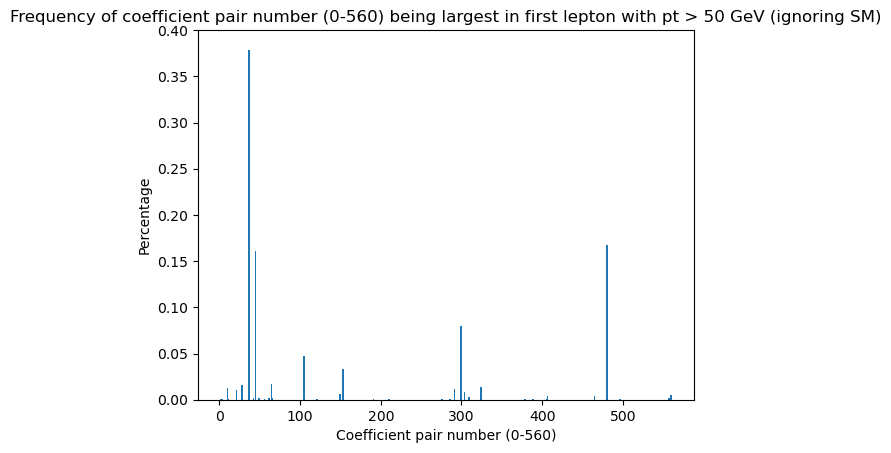

The pair ['ctG', 'SM'] with index 36.0 has 37.81%
The pair ['cQq11', 'cQq13'] with index 480.0 has 16.761%
The pair ['ctG', 'ctG'] with index 44.0 has 16.071%
The pair ['ctq1', 'ctq1'] with index 299.0 has 8.023%
The pair ['cbW', 'cbW'] with index 104.0 has 4.752%
The pair ['cptb', 'cptb'] with index 152.0 has 3.253%
The pair ['ctW', 'ctZ'] with index 64.0 has 1.667%
The pair ['cpQ3', 'cpQ3'] with index 27.0 has 1.616%
The pair ['ctu1', 'ctu1'] with index 324.0 has 1.427%
The pair ['cQu1', 'cQu1'] with index 9.0 has 1.282%
The pair ['ctq1', 'cQq13'] with index 291.0 has 1.199%
The pair ['cpQ3', 'SM'] with index 21.0 has 1.067%


In [89]:
# Plotting histogram for first lepton and also printing the interesting coefficients (higher than 5%)
plt.hist(eft_coeff_first_leptons, bins = 500, weights = weights(eft_coeff_first_leptons), width = 2)
plt.xlabel('Coefficient pair number (0-560)')
plt.ylabel('Percentage')
plt.title('Frequency of coefficient pair number (0-560) being largest in first lepton with pt > 50 GeV (ignoring SM)')
plt.ylim(0,0.4)
plt.show()

interesting_coeff(eft_coeff_first_leptons)

### _Results for second lepton using my code_

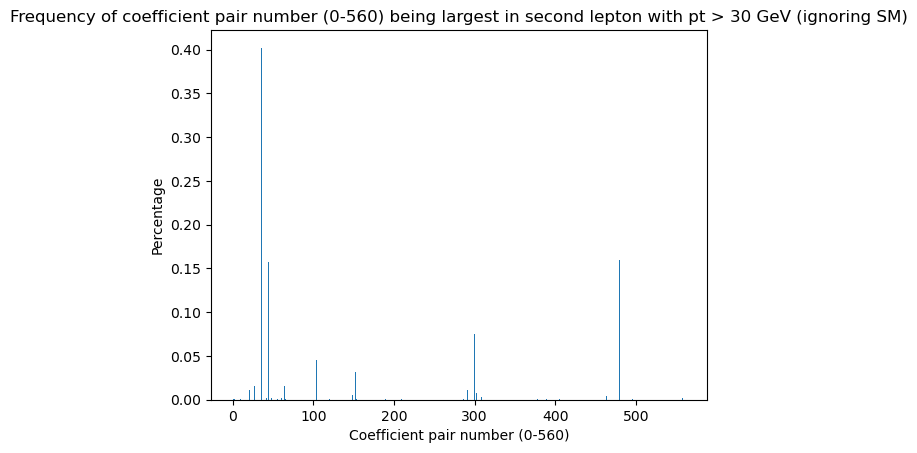

The pair ['ctG', 'SM'] with index 36.0 has 40.211%
The pair ['cQq11', 'cQq13'] with index 480.0 has 15.942%
The pair ['ctG', 'ctG'] with index 44.0 has 15.718%
The pair ['ctq1', 'ctq1'] with index 299.0 has 7.512%
The pair ['cbW', 'cbW'] with index 104.0 has 4.584%
The pair ['cptb', 'cptb'] with index 152.0 has 3.164%
The pair ['ctW', 'ctZ'] with index 64.0 has 1.537%
The pair ['cpQ3', 'cpQ3'] with index 27.0 has 1.532%
The pair ['ctu1', 'ctu1'] with index 324.0 has 1.34%
The pair ['cQu1', 'cQu1'] with index 9.0 has 1.198%
The pair ['cpQ3', 'SM'] with index 21.0 has 1.165%
The pair ['ctq1', 'cQq13'] with index 291.0 has 1.123%


In [90]:
# Plotting histogram for second lepton and also the interesting coefficients (higher than 5%)
plt.hist(eft_coeff_second_leptons, bins = 520, weights = weights(eft_coeff_second_leptons))
plt.xlabel('Coefficient pair number (0-560)')
plt.ylabel('Percentage')
plt.title('Frequency of coefficient pair number (0-560) being largest in second lepton with pt > 30 GeV (ignoring SM)')
plt.show()

interesting_coeff(eft_coeff_second_leptons)